In [1]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import DBSCAN

# 1
### 1.1 Paths

In [2]:
random_seed = 42

step1_results_dir = Path("./results_step1")
step2_results_dir = Path("./results_step2")

step3_results_dir = Path("./results_step3")
step3_results_dir.mkdir(exist_ok=True, parents=True)

np.random.seed(random_seed)
random.seed(random_seed)

seed = random_seed
seed

42

### 1.2 Helper functions

In [3]:
def require_files(directory_path, file_names):
    missing_files = [
        file_name
        for file_name in file_names
        if not (directory_path / file_name).exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            f"missing required files in {directory_path}: {missing_files}"
        )


def get_embedding_columns(df, prefix):
    cols = [
        col
        for col in df.columns
        if isinstance(col, str) and col.startswith(prefix)
    ]

    cols = sorted(cols)

    if not cols:
        raise ValueError(f"no embedding columns found with prefix {prefix}")

    return cols


def check_numeric_matrix(matrix, name):
    if not np.issubdtype(matrix.dtype, np.number):
        raise TypeError(f"{name} is not numeric")

    if not np.isfinite(matrix).all():
        bad_count = int((~np.isfinite(matrix)).sum())
        raise ValueError(f"{name} contains non-finite values: {bad_count}")

    if matrix.ndim != 2:
        raise ValueError(f"{name} must be 2-dimensional")

    if matrix.shape[0] < 2:
        raise ValueError(f"{name} must contain at least 2 rows")

    if matrix.shape[1] < 2:
        raise ValueError(f"{name} must contain at least 2 columns")


def make_json_serializable(obj):
    if isinstance(obj, dict):
        return {
            str(key): make_json_serializable(value)
            for key, value in obj.items()
        }

    if isinstance(obj, list):
        return [
            make_json_serializable(value)
            for value in obj
        ]

    if isinstance(obj, tuple):
        return [
            make_json_serializable(value)
            for value in obj
        ]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        if np.isnan(obj):
            return None
        return float(obj)

    if isinstance(obj, (np.bool_,)):
        return bool(obj)

    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    if obj is pd.NaT:
        return None

    if obj is None:
        return None

    try:
        if pd.isna(obj):
            return None
    except (TypeError, ValueError):
        pass

    return obj

### 2.1 Load step 2 artifacts

In [4]:
required_step2_files = [
    "user_embeddings_final.parquet",
    "item_embeddings_final.parquet",
    "user_embeddings_p_u.npy",
    "item_embeddings_q_i.npy",
    "user_index_mapping.parquet",
    "item_index_mapping.parquet",
    "final_step2_config.json",
]

require_files(step2_results_dir, required_step2_files)

user_embeddings = pd.read_parquet(
    step2_results_dir / "user_embeddings_final.parquet"
)

item_embeddings = pd.read_parquet(
    step2_results_dir / "item_embeddings_final.parquet"
)

user_embedding_matrix_from_file = np.load(
    step2_results_dir / "user_embeddings_p_u.npy"
)

item_embedding_matrix_from_file = np.load(
    step2_results_dir / "item_embeddings_q_i.npy"
)

user_index_mapping = pd.read_parquet(
    step2_results_dir / "user_index_mapping.parquet"
)

item_index_mapping = pd.read_parquet(
    step2_results_dir / "item_index_mapping.parquet"
)

with open(step2_results_dir / "final_step2_config.json", "r") as f:
    step2_config = json.load(f)

load_summary = pd.DataFrame([
    {
        "artifact": "user_embeddings",
        "rows": len(user_embeddings),
        "columns": user_embeddings.shape[1],
    },
    {
        "artifact": "item_embeddings",
        "rows": len(item_embeddings),
        "columns": item_embeddings.shape[1],
    },
    {
        "artifact": "user_embedding_matrix_from_file",
        "rows": user_embedding_matrix_from_file.shape[0],
        "columns": user_embedding_matrix_from_file.shape[1],
    },
    {
        "artifact": "item_embedding_matrix_from_file",
        "rows": item_embedding_matrix_from_file.shape[0],
        "columns": item_embedding_matrix_from_file.shape[1],
    },
    {
        "artifact": "user_index_mapping",
        "rows": len(user_index_mapping),
        "columns": user_index_mapping.shape[1],
    },
    {
        "artifact": "item_index_mapping",
        "rows": len(item_index_mapping),
        "columns": item_index_mapping.shape[1],
    },
])

display(load_summary)

,artifact,rows,columns
0,user_embeddings,4722,70
1,item_embeddings,3250,69
2,user_embedding_matrix_from_file,4722,64
3,item_embedding_matrix_from_file,3250,64
4,user_index_mapping,4722,2
5,item_index_mapping,3250,2


### 2.2 Extract only embedding columns

In [5]:
user_embedding_cols = get_embedding_columns(
    user_embeddings,
    "p_",
)

item_embedding_cols = get_embedding_columns(
    item_embeddings,
    "q_",
)

user_matrix = (
    user_embeddings[user_embedding_cols]
    .to_numpy(dtype=np.float64)
)

item_matrix = (
    item_embeddings[item_embedding_cols]
    .to_numpy(dtype=np.float64)
)

check_numeric_matrix(user_matrix, "user_matrix")
check_numeric_matrix(item_matrix, "item_matrix")

feature_check_summary = pd.DataFrame([
    {
        "space": "user",
        "rows": user_matrix.shape[0],
        "embedding_dimensions": user_matrix.shape[1],
        "embedding_columns": len(user_embedding_cols),
        "matrix_file_rows": user_embedding_matrix_from_file.shape[0],
        "matrix_file_dimensions": user_embedding_matrix_from_file.shape[1],
        "matches_numpy_file_shape": user_matrix.shape == user_embedding_matrix_from_file.shape,
        "max_abs_difference_from_numpy_file": float(
            np.max(np.abs(user_matrix - user_embedding_matrix_from_file))
        ),
    },
    {
        "space": "item",
        "rows": item_matrix.shape[0],
        "embedding_dimensions": item_matrix.shape[1],
        "embedding_columns": len(item_embedding_cols),
        "matrix_file_rows": item_embedding_matrix_from_file.shape[0],
        "matrix_file_dimensions": item_embedding_matrix_from_file.shape[1],
        "matches_numpy_file_shape": item_matrix.shape == item_embedding_matrix_from_file.shape,
        "max_abs_difference_from_numpy_file": float(
            np.max(np.abs(item_matrix - item_embedding_matrix_from_file))
        ),
    },
])

display(feature_check_summary)

assert feature_check_summary["matches_numpy_file_shape"].all()
assert feature_check_summary["max_abs_difference_from_numpy_file"].max() < 1e-10

,space,rows,embedding_dimensions,embedding_columns,matrix_file_rows,matrix_file_dimensions,matches_numpy_file_shape,max_abs_difference_from_numpy_file
0,user,4722,64,64,4722,64,True,0.0
1,item,3250,64,64,3250,64,True,0.0


### 2.3 Verify that non-embedding columns are not used

In [6]:
user_numeric_non_embedding_cols = [
    col
    for col in user_embeddings.select_dtypes(include=[np.number]).columns
    if col not in user_embedding_cols
]

item_numeric_non_embedding_cols = [
    col
    for col in item_embeddings.select_dtypes(include=[np.number]).columns
    if col not in item_embedding_cols
]

non_embedding_column_summary = pd.DataFrame([
    {
        "space": "user",
        "numeric_non_embedding_columns_not_used": user_numeric_non_embedding_cols,
        "count": len(user_numeric_non_embedding_cols),
    },
    {
        "space": "item",
        "numeric_non_embedding_columns_not_used": item_numeric_non_embedding_cols,
        "count": len(item_numeric_non_embedding_cols),
    },
])

display(non_embedding_column_summary)

,space,numeric_non_embedding_columns_not_used,count
0,user,"[user_idx, user_id, age, occupation]",4
1,item,"[item_idx, movie_id, item_bias]",3


### 2.4 Base embedding diagnostics

In [7]:
def summarize_matrix(matrix, space_name):
    row_norms = np.linalg.norm(matrix, axis=1)
    col_means = matrix.mean(axis=0)
    col_stds = matrix.std(axis=0)

    return {
        "space": space_name,
        "rows": matrix.shape[0],
        "dimensions": matrix.shape[1],
        "row_norm_min": float(np.min(row_norms)),
        "row_norm_q25": float(np.quantile(row_norms, 0.25)),
        "row_norm_median": float(np.quantile(row_norms, 0.50)),
        "row_norm_q75": float(np.quantile(row_norms, 0.75)),
        "row_norm_max": float(np.max(row_norms)),
        "column_mean_abs_mean": float(np.mean(np.abs(col_means))),
        "column_std_min": float(np.min(col_stds)),
        "column_std_median": float(np.median(col_stds)),
        "column_std_max": float(np.max(col_stds)),
    }


base_embedding_summary = pd.DataFrame([
    summarize_matrix(user_matrix, "user"),
    summarize_matrix(item_matrix, "item"),
])

display(base_embedding_summary)

,space,rows,dimensions,row_norm_min,row_norm_q25,row_norm_median,row_norm_q75,row_norm_max,column_mean_abs_mean,column_std_min,column_std_median,column_std_max
0,user,4722,64,0.753706,1.651800,1.969063,2.254411,3.274429,0.129031,0.153437,0.19779,0.278227
1,item,3250,64,0.291399,1.488301,1.864486,2.317500,4.527428,0.044607,0.213309,0.24154,0.314141


# 3 User DBSCAN 
### Build raw and PCA spaces

In [8]:
assert "user_matrix" in globals(), "user_matrix must be loaded before Step 3."
assert user_matrix.ndim == 2, "user_matrix must be a 2D matrix."
assert user_matrix.shape[1] == 64

In [9]:
pca_dimensions = [10, 20, 30]

user_spaces = {}

user_scaled = StandardScaler().fit_transform(user_matrix)

user_spaces["user_l2_cosine"] = {
    "matrix": normalize(user_matrix, norm="l2", axis=1),
    "metric": "cosine",
    "dimensions": 64,
    "preprocessing": "l2",
    "pca_variance": np.nan,
}

user_spaces["user_standardized_euclidean"] = {
    "matrix": user_scaled,
    "metric": "euclidean",
    "dimensions": 64,
    "preprocessing": "standardized",
    "pca_variance": np.nan,
}

user_spaces["user_standardized_l2_cosine"] = {
    "matrix": normalize(user_scaled, norm="l2", axis=1),
    "metric": "cosine",
    "dimensions": 64,
    "preprocessing": "standardized_l2",
    "pca_variance": np.nan,
}

for n_components in pca_dimensions:
    pca = PCA(n_components=n_components, random_state=seed)
    user_pca = pca.fit_transform(user_scaled)
    user_pca_scaled = StandardScaler().fit_transform(user_pca)

    user_spaces[f"user_pca{n_components}_l2_cosine"] = {
        "matrix": normalize(user_pca, norm="l2", axis=1),
        "metric": "cosine",
        "dimensions": n_components,
        "preprocessing": f"pca{n_components}_l2",
        "pca_variance": float(pca.explained_variance_ratio_.sum()),
    }

    user_spaces[f"user_pca{n_components}_standardized_euclidean"] = {
        "matrix": user_pca_scaled,
        "metric": "euclidean",
        "dimensions": n_components,
        "preprocessing": f"pca{n_components}_standardized",
        "pca_variance": float(pca.explained_variance_ratio_.sum()),
    }

    user_spaces[f"user_pca{n_components}_standardized_l2_cosine"] = {
        "matrix": normalize(user_pca_scaled, norm="l2", axis=1),
        "metric": "cosine",
        "dimensions": n_components,
        "preprocessing": f"pca{n_components}_standardized_l2",
        "pca_variance": float(pca.explained_variance_ratio_.sum()),
    }

user_space_summary = pd.DataFrame([
    {
        "space_name": space_name,
        "rows": space_data["matrix"].shape[0],
        "dimensions": space_data["matrix"].shape[1],
        "metric": space_data["metric"],
        "preprocessing": space_data["preprocessing"],
        "pca_variance": space_data["pca_variance"],
    }
    for space_name, space_data in user_spaces.items()
])

display(user_space_summary.round(4))
print("User spaces:", len(user_spaces))

,space_name,rows,dimensions,metric,preprocessing,pca_variance
0,user_l2_cosine,4722,64,cosine,l2,NaN
1,user_standardized_euclidean,4722,64,euclidean,standardized,NaN
2,user_standardized_l2_cosine,4722,64,cosine,standardized_l2,NaN
3,user_pca10_l2_cosine,4722,10,cosine,pca10_l2,0.5271
4,user_pca10_standardized_euclidean,4722,10,euclidean,pca10_standardized,0.5271
5,user_pca10_standardized_l2_cosine,4722,10,cosine,pca10_standardized_l2,0.5271
6,user_pca20_l2_cosine,4722,20,cosine,pca20_l2,0.6807
7,user_pca20_standardized_euclidean,4722,20,euclidean,pca20_standardized,0.6807
8,user_pca20_standardized_l2_cosine,4722,20,cosine,pca20_standardized_l2,0.6807
9,user_pca30_l2_cosine,4722,30,cosine,pca30_l2,0.7921


User spaces: 12


### 3.1 User DBSCAN tuning grid

In [10]:
min_samples_by_dim = {
    10: [5, 11, 20],
    20: [5, 11, 21, 40],
    30: [5, 16, 31, 60],
    64: [5, 33, 65, 128],
}

eps_percentiles = [
    1, 2.5, 5, 10,
    15, 20, 25, 30, 35, 40, 45, 50,
    60, 70,
    80, 85, 90, 95, 99,
]

user_grid_rows = []

for space_name, space_data in user_spaces.items():
    dimensions = space_data["dimensions"]
    min_samples_grid = min_samples_by_dim[dimensions]

    for min_samples in min_samples_grid:
        user_grid_rows.append({
            "space_name": space_name,
            "dimensions": dimensions,
            "metric": space_data["metric"],
            "preprocessing": space_data["preprocessing"],
            "min_samples": min_samples,
        })

user_grid = pd.DataFrame(user_grid_rows)

display(user_grid)

print("User space/min_samples combinations:", len(user_grid))
print("Expected user DBSCAN runs:", len(user_grid) * len(eps_percentiles))

,space_name,dimensions,metric,preprocessing,min_samples
0,user_l2_cosine,64,cosine,l2,5
1,user_l2_cosine,64,cosine,l2,33
2,user_l2_cosine,64,cosine,l2,65
3,user_l2_cosine,64,cosine,l2,128
4,user_standardized_euclidean,64,euclidean,standardized,5
5,user_standardized_euclidean,64,euclidean,standardized,33
6,user_standardized_euclidean,64,euclidean,standardized,65
7,user_standardized_euclidean,64,euclidean,standardized,128
8,user_standardized_l2_cosine,64,cosine,standardized_l2,5
9,user_standardized_l2_cosine,64,cosine,standardized_l2,33


User space/min_samples combinations: 45
Expected user DBSCAN runs: 855


### 3.2 User k-distance percentiles for eps candidates

In [11]:
user_eps_rows = []

for row in user_grid.itertuples(index=False):
    matrix = user_spaces[row.space_name]["matrix"]

    neighbors = NearestNeighbors(
        n_neighbors=int(row.min_samples),
        metric=row.metric,
        n_jobs=-1,
    )

    neighbors.fit(matrix)
    distances, _ = neighbors.kneighbors(matrix)

    k_distances = distances[:, -1]
    eps_values = np.percentile(k_distances, eps_percentiles)

    for percentile, eps in zip(eps_percentiles, eps_values):
        eps = round(float(eps), 6)

        if eps <= 0:
            continue

        user_eps_rows.append({
            "space_name": row.space_name,
            "dimensions": int(row.dimensions),
            "metric": row.metric,
            "preprocessing": row.preprocessing,
            "min_samples": int(row.min_samples),
            "eps_percentile": percentile,
            "eps": eps,
            "k_distance_min": float(np.min(k_distances)),
            "k_distance_median": float(np.median(k_distances)),
            "k_distance_max": float(np.max(k_distances)),
        })

user_eps_grid = (
    pd.DataFrame(user_eps_rows)
    .drop_duplicates(["space_name", "min_samples", "eps"])
    .sort_values(["space_name", "min_samples", "eps"])
    .reset_index(drop=True)
)

display(user_eps_grid.head(20))
print("User DBSCAN runs:", len(user_eps_grid))

,space_name,dimensions,metric,preprocessing,min_samples,eps_percentile,eps,k_distance_min,k_distance_median,k_distance_max
0,user_l2_cosine,64,cosine,l2,5,1.0,0.067723,0.040500,0.264159,0.720669
1,user_l2_cosine,64,cosine,l2,5,2.5,0.083288,0.040500,0.264159,0.720669
2,user_l2_cosine,64,cosine,l2,5,5.0,0.098182,0.040500,0.264159,0.720669
3,user_l2_cosine,64,cosine,l2,5,10.0,0.121192,0.040500,0.264159,0.720669
4,user_l2_cosine,64,cosine,l2,5,15.0,0.143412,0.040500,0.264159,0.720669
5,user_l2_cosine,64,cosine,l2,5,20.0,0.163469,0.040500,0.264159,0.720669
6,user_l2_cosine,64,cosine,l2,5,25.0,0.180723,0.040500,0.264159,0.720669
7,user_l2_cosine,64,cosine,l2,5,30.0,0.197269,0.040500,0.264159,0.720669
8,user_l2_cosine,64,cosine,l2,5,35.0,0.213987,0.040500,0.264159,0.720669
9,user_l2_cosine,64,cosine,l2,5,40.0,0.230401,0.040500,0.264159,0.720669


User DBSCAN runs: 855


### 3.3 Run User DBSCAN grid

In [12]:
user_dbscan_runs = {}
user_dbscan_summary_rows = []

for run_id, row in enumerate(user_eps_grid.itertuples(index=False), start=1):
    matrix = user_spaces[row.space_name]["matrix"]

    model = DBSCAN(
        eps=float(row.eps),
        min_samples=int(row.min_samples),
        metric=row.metric,
        n_jobs=-1,
    )

    labels = model.fit_predict(matrix)

    label_counts = pd.Series(labels).value_counts().sort_index()
    cluster_counts = label_counts[label_counts.index != -1]

    n_points = len(labels)
    noise_count = int((labels == -1).sum())
    clustered_count = n_points - noise_count
    n_clusters = int(len(cluster_counts))

    if n_clusters > 0:
        largest_cluster_size = int(cluster_counts.max())
        smallest_cluster_size = int(cluster_counts.min())
        median_cluster_size = float(cluster_counts.median())
        mean_cluster_size = float(cluster_counts.mean())
        largest_cluster_share_all = largest_cluster_size / n_points
        largest_cluster_share_clustered = largest_cluster_size / clustered_count
    else:
        largest_cluster_size = 0
        smallest_cluster_size = 0
        median_cluster_size = np.nan
        mean_cluster_size = np.nan
        largest_cluster_share_all = 0.0
        largest_cluster_share_clustered = 0.0

    run_key = f"user_run_{run_id:04d}"

    user_dbscan_runs[run_key] = {
        "labels": labels,
        "space_name": row.space_name,
        "eps": float(row.eps),
        "eps_percentile": row.eps_percentile,
        "min_samples": int(row.min_samples),
        "metric": row.metric,
    }

    user_dbscan_summary_rows.append({
        "run_key": run_key,
        "space_name": row.space_name,
        "dimensions": int(row.dimensions),
        "preprocessing": row.preprocessing,
        "metric": row.metric,
        "min_samples": int(row.min_samples),
        "eps_percentile": row.eps_percentile,
        "eps": float(row.eps),
        "n_points": n_points,
        "n_clusters": n_clusters,
        "noise_count": noise_count,
        "noise_share": noise_count / n_points,
        "clustered_count": clustered_count,
        "clustered_share": clustered_count / n_points,
        "largest_cluster_size": largest_cluster_size,
        "largest_cluster_share_all": largest_cluster_share_all,
        "largest_cluster_share_clustered": largest_cluster_share_clustered,
        "smallest_cluster_size": smallest_cluster_size,
        "median_cluster_size": median_cluster_size,
        "mean_cluster_size": mean_cluster_size,
    })

user_dbscan_summary = (
    pd.DataFrame(user_dbscan_summary_rows)
    .sort_values(["space_name", "min_samples", "eps"])
    .reset_index(drop=True)
)

user_dbscan_summary.to_csv(
    step3_results_dir / "user_dbscan_grid_summary.csv",
    index=False,
)

display(user_dbscan_summary.head(20).round(4))
print("Finished user DBSCAN runs:", len(user_dbscan_summary))

,run_key,space_name,dimensions,preprocessing,metric,min_samples,eps_percentile,eps,n_points,n_clusters,noise_count,noise_share,clustered_count,clustered_share,largest_cluster_size,largest_cluster_share_all,largest_cluster_share_clustered,smallest_cluster_size,median_cluster_size,mean_cluster_size
0,user_run_0001,user_l2_cosine,64,l2,cosine,5,1.0,0.0677,4722,2,4623,0.9790,99,0.0210,94,0.0199,0.9495,5,49.5,49.5
1,user_run_0002,user_l2_cosine,64,l2,cosine,5,2.5,0.0833,4722,1,4494,0.9517,228,0.0483,228,0.0483,1.0000,228,228.0,228.0
2,user_run_0003,user_l2_cosine,64,l2,cosine,5,5.0,0.0982,4722,1,4321,0.9151,401,0.0849,401,0.0849,1.0000,401,401.0,401.0
3,user_run_0004,user_l2_cosine,64,l2,cosine,5,10.0,0.1212,4722,1,4057,0.8592,665,0.1408,665,0.1408,1.0000,665,665.0,665.0
4,user_run_0005,user_l2_cosine,64,l2,cosine,5,15.0,0.1434,4722,1,3771,0.7986,951,0.2014,951,0.2014,1.0000,951,951.0,951.0
5,user_run_0006,user_l2_cosine,64,l2,cosine,5,20.0,0.1635,4722,2,3500,0.7412,1222,0.2588,1219,0.2582,0.9975,3,611.0,611.0
6,user_run_0007,user_l2_cosine,64,l2,cosine,5,25.0,0.1807,4722,1,3222,0.6823,1500,0.3177,1500,0.3177,1.0000,1500,1500.0,1500.0
7,user_run_0008,user_l2_cosine,64,l2,cosine,5,30.0,0.1973,4722,1,2954,0.6256,1768,0.3744,1768,0.3744,1.0000,1768,1768.0,1768.0
8,user_run_0009,user_l2_cosine,64,l2,cosine,5,35.0,0.2140,4722,1,2712,0.5743,2010,0.4257,2010,0.4257,1.0000,2010,2010.0,2010.0
9,user_run_0010,user_l2_cosine,64,l2,cosine,5,40.0,0.2304,4722,1,2411,0.5106,2311,0.4894,2311,0.4894,1.0000,2311,2311.0,2311.0


Finished user DBSCAN runs: 855


### 3.4 User DBSCAN filter

In [13]:
# Filter keeps only minimally viable clusterings:
# at least 2 non-noise clusters and no more than 65% noise.
# and no more than 90% of clustered points in a single cluster (to avoid extreme imbalance)
user_stage1 = user_dbscan_summary[
    (user_dbscan_summary["n_clusters"] >= 2) &
    (user_dbscan_summary["noise_share"] <= 0.65) &
    (user_dbscan_summary["largest_cluster_share_clustered"] <= 0.90)
].copy()

user_stage1 = (
    user_stage1
    .sort_values([
        "space_name",
        "n_clusters",
        "noise_share",
        "largest_cluster_share_clustered",
    ])
    .reset_index(drop=True)
)

user_stage1.to_csv(
    step3_results_dir / "user_dbscan_stage1_candidates.csv",
    index=False,
)

display(user_stage1.round(4))

print("User DBSCAN runs:", len(user_dbscan_summary))
print("User Stage 1 candidates:", len(user_stage1))

,run_key,space_name,dimensions,preprocessing,metric,min_samples,eps_percentile,eps,n_points,n_clusters,noise_count,noise_share,clustered_count,clustered_share,largest_cluster_size,largest_cluster_share_all,largest_cluster_share_clustered,smallest_cluster_size,median_cluster_size,mean_cluster_size
0,user_run_0232,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,20,10.0,0.2228,4722,17,1904,0.4032,2818,0.5968,2517,0.5330,0.8932,10,16.0,165.7647
1,user_run_0214,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,11,15.0,0.1901,4722,29,1773,0.3755,2949,0.6245,2587,0.5479,0.8772,4,10.0,101.6897
2,user_run_0213,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,11,10.0,0.1839,4722,33,2538,0.5375,2184,0.4625,1762,0.3731,0.8068,5,11.0,66.1818
3,user_run_0198,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,30.0,0.1548,4722,81,1514,0.3206,3208,0.6794,2695,0.5707,0.8401,2,5.0,39.6049
4,user_run_0197,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,25.0,0.1514,4722,113,1829,0.3873,2893,0.6127,2177,0.4610,0.7525,1,5.0,25.6018
5,user_run_0196,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,20.0,0.1472,4722,136,2234,0.4731,2488,0.5269,1592,0.3371,0.6399,2,5.0,18.2941
6,user_run_0195,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,15.0,0.1422,4722,142,2726,0.5773,1996,0.4227,766,0.1622,0.3838,3,5.0,14.0563
7,user_run_0309,user_pca20_l2_cosine,20,pca20_l2,cosine,40,15.0,0.2424,4722,3,2632,0.5574,2090,0.4426,1194,0.2529,0.5713,18,878.0,696.6667
8,user_run_0290,user_pca20_l2_cosine,20,pca20_l2,cosine,21,15.0,0.2133,4722,3,2955,0.6258,1767,0.3742,1044,0.2211,0.5908,15,708.0,589.0000
9,user_run_0422,user_pca20_standardized_l2_cosine,20,pca20_standardized_l2,cosine,11,10.0,0.3647,4722,29,2264,0.4795,2458,0.5205,2152,0.4557,0.8755,5,10.0,84.7586


User DBSCAN runs: 855
User Stage 1 candidates: 21


In [14]:
user_stage1_view = user_stage1[
    [
        "run_key",
        "space_name",
        "dimensions",
        "preprocessing",
        "metric",
        "min_samples",
        "eps_percentile",
        "eps",
        "n_clusters",
        "noise_share",
        "largest_cluster_share_clustered",
        "smallest_cluster_size",
        "median_cluster_size",
    ]
].copy()

display(user_stage1_view.round(4))

,run_key,space_name,dimensions,preprocessing,metric,min_samples,eps_percentile,eps,n_clusters,noise_share,largest_cluster_share_clustered,smallest_cluster_size,median_cluster_size
0,user_run_0232,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,20,10.0,0.2228,17,0.4032,0.8932,10,16.0
1,user_run_0214,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,11,15.0,0.1901,29,0.3755,0.8772,4,10.0
2,user_run_0213,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,11,10.0,0.1839,33,0.5375,0.8068,5,11.0
3,user_run_0198,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,30.0,0.1548,81,0.3206,0.8401,2,5.0
4,user_run_0197,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,25.0,0.1514,113,0.3873,0.7525,1,5.0
5,user_run_0196,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,20.0,0.1472,136,0.4731,0.6399,2,5.0
6,user_run_0195,user_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,15.0,0.1422,142,0.5773,0.3838,3,5.0
7,user_run_0309,user_pca20_l2_cosine,20,pca20_l2,cosine,40,15.0,0.2424,3,0.5574,0.5713,18,878.0
8,user_run_0290,user_pca20_l2_cosine,20,pca20_l2,cosine,21,15.0,0.2133,3,0.6258,0.5908,15,708.0
9,user_run_0422,user_pca20_standardized_l2_cosine,20,pca20_standardized_l2,cosine,11,10.0,0.3647,29,0.4795,0.8755,5,10.0


In [15]:
# cluster-size summary for Stage 1 user DBSCAN candidates

stage1_cluster_size_rows = []

for run_key in user_stage1["run_key"]:
    labels = np.asarray(user_dbscan_runs[run_key]["labels"]).astype(int)

    sizes = pd.Series(labels).value_counts().sort_index()
    non_noise_sizes = sizes[sizes.index != -1]

    stage1_cluster_size_rows.append({
        "run_key": run_key,
        "n_clusters": len(non_noise_sizes),
        "noise_size": int(sizes.get(-1, 0)),
        "noise_share": float(sizes.get(-1, 0) / len(labels)),
        "cluster_sizes_desc": " | ".join(
            map(str, non_noise_sizes.sort_values(ascending=False).astype(int).tolist())
        ),
    })

stage1_cluster_size_summary = pd.DataFrame(stage1_cluster_size_rows)

stage1_cluster_size_summary = stage1_cluster_size_summary.merge(
    user_stage1[
        [
            "run_key",
            "space_name",
            "preprocessing",
            "metric",
            "min_samples",
            "eps_percentile",
            "eps",
        ]
    ],
    on="run_key",
    how="left",
)

stage1_cluster_size_summary = stage1_cluster_size_summary[
    [
        "run_key",
        "space_name",
        "min_samples",
        "eps_percentile",
        "eps",
        "n_clusters",
        "noise_size",
        "noise_share",
        "cluster_sizes_desc",
    ]
]

display(stage1_cluster_size_summary.round(4))

,run_key,space_name,min_samples,eps_percentile,eps,n_clusters,noise_size,noise_share,cluster_sizes_desc
0,user_run_0232,user_pca10_standardized_l2_cosine,20,10.0,0.2228,17,1904,0.4032,2517 | 51 | 34 | 30 | 19 | 18 | 17 | 16 | 16 |...
1,user_run_0214,user_pca10_standardized_l2_cosine,11,15.0,0.1901,29,1773,0.3755,2587 | 48 | 34 | 21 | 19 | 18 | 16 | 15 | 13 |...
2,user_run_0213,user_pca10_standardized_l2_cosine,11,10.0,0.1839,33,2538,0.5375,1762 | 35 | 24 | 23 | 23 | 20 | 18 | 18 | 18 |...
3,user_run_0198,user_pca10_standardized_l2_cosine,5,30.0,0.1548,81,1514,0.3206,2695 | 24 | 23 | 21 | 16 | 15 | 15 | 14 | 13 |...
4,user_run_0197,user_pca10_standardized_l2_cosine,5,25.0,0.1514,113,1829,0.3873,2177 | 24 | 22 | 20 | 17 | 17 | 17 | 16 | 16 |...
5,user_run_0196,user_pca10_standardized_l2_cosine,5,20.0,0.1472,136,2234,0.4731,1592 | 54 | 28 | 22 | 21 | 19 | 16 | 15 | 15 |...
6,user_run_0195,user_pca10_standardized_l2_cosine,5,15.0,0.1422,142,2726,0.5773,766 | 131 | 75 | 71 | 58 | 24 | 23 | 21 | 20 |...
7,user_run_0309,user_pca20_l2_cosine,40,15.0,0.2424,3,2632,0.5574,1194 | 878 | 18
8,user_run_0290,user_pca20_l2_cosine,21,15.0,0.2133,3,2955,0.6258,1044 | 708 | 15
9,user_run_0422,user_pca20_standardized_l2_cosine,11,10.0,0.3647,29,2264,0.4795,2152 | 30 | 20 | 18 | 14 | 13 | 12 | 12 | 12 |...


In [16]:
stage1_cluster_size_summary.to_csv(
    step3_results_dir / "user_stage1_cluster_size_summary.csv",
    index=False,
)

# Item DBSCAN 
### 3.5 Build item preprocessing spaces

In [17]:
assert item_matrix.ndim == 2

item_spaces = {}

item_scaled = StandardScaler().fit_transform(item_matrix)

item_spaces["item_l2_cosine"] = {
    "matrix": normalize(item_matrix, norm="l2", axis=1),
    "metric": "cosine",
    "dimensions": item_matrix.shape[1],
    "preprocessing": "l2",
    "pca_variance": np.nan,
}

item_spaces["item_standardized_euclidean"] = {
    "matrix": item_scaled,
    "metric": "euclidean",
    "dimensions": item_matrix.shape[1],
    "preprocessing": "standardized",
    "pca_variance": np.nan,
}

item_spaces["item_standardized_l2_cosine"] = {
    "matrix": normalize(item_scaled, norm="l2", axis=1),
    "metric": "cosine",
    "dimensions": item_matrix.shape[1],
    "preprocessing": "standardized_l2",
    "pca_variance": np.nan,
}

for n_components in pca_dimensions:
    pca = PCA(n_components=n_components, random_state=seed)
    item_pca = pca.fit_transform(item_scaled)
    item_pca_scaled = StandardScaler().fit_transform(item_pca)

    item_spaces[f"item_pca{n_components}_l2_cosine"] = {
        "matrix": normalize(item_pca, norm="l2", axis=1),
        "metric": "cosine",
        "dimensions": n_components,
        "preprocessing": f"pca{n_components}_l2",
        "pca_variance": float(pca.explained_variance_ratio_.sum()),
    }

    item_spaces[f"item_pca{n_components}_standardized_euclidean"] = {
        "matrix": item_pca_scaled,
        "metric": "euclidean",
        "dimensions": n_components,
        "preprocessing": f"pca{n_components}_standardized",
        "pca_variance": float(pca.explained_variance_ratio_.sum()),
    }

    item_spaces[f"item_pca{n_components}_standardized_l2_cosine"] = {
        "matrix": normalize(item_pca_scaled, norm="l2", axis=1),
        "metric": "cosine",
        "dimensions": n_components,
        "preprocessing": f"pca{n_components}_standardized_l2",
        "pca_variance": float(pca.explained_variance_ratio_.sum()),
    }

item_space_summary = pd.DataFrame([
    {
        "space_name": space_name,
        "rows": space_data["matrix"].shape[0],
        "dimensions": space_data["matrix"].shape[1],
        "metric": space_data["metric"],
        "preprocessing": space_data["preprocessing"],
        "pca_variance": space_data["pca_variance"],
    }
    for space_name, space_data in item_spaces.items()
])

display(item_space_summary.round(4))
print("Item spaces:", len(item_spaces))

,space_name,rows,dimensions,metric,preprocessing,pca_variance
0,item_l2_cosine,3250,64,cosine,l2,NaN
1,item_standardized_euclidean,3250,64,euclidean,standardized,NaN
2,item_standardized_l2_cosine,3250,64,cosine,standardized_l2,NaN
3,item_pca10_l2_cosine,3250,10,cosine,pca10_l2,0.6717
4,item_pca10_standardized_euclidean,3250,10,euclidean,pca10_standardized,0.6717
5,item_pca10_standardized_l2_cosine,3250,10,cosine,pca10_standardized_l2,0.6717
6,item_pca20_l2_cosine,3250,20,cosine,pca20_l2,0.7768
7,item_pca20_standardized_euclidean,3250,20,euclidean,pca20_standardized,0.7768
8,item_pca20_standardized_l2_cosine,3250,20,cosine,pca20_standardized_l2,0.7768
9,item_pca30_l2_cosine,3250,30,cosine,pca30_l2,0.8525


Item spaces: 12


### 3.6 Item DBSCAN grid

In [18]:
item_grid_rows = []

for space_name, space_data in item_spaces.items():
    for min_samples in min_samples_by_dim[space_data["dimensions"]]:
        item_grid_rows.append({
            "space_name": space_name,
            "dimensions": space_data["dimensions"],
            "metric": space_data["metric"],
            "preprocessing": space_data["preprocessing"],
            "min_samples": min_samples,
        })

item_grid = pd.DataFrame(item_grid_rows)

display(item_grid)

print("Item space/min_samples combinations:", len(item_grid))
print("Expected item DBSCAN runs:", len(item_grid) * len(eps_percentiles))

,space_name,dimensions,metric,preprocessing,min_samples
0,item_l2_cosine,64,cosine,l2,5
1,item_l2_cosine,64,cosine,l2,33
2,item_l2_cosine,64,cosine,l2,65
3,item_l2_cosine,64,cosine,l2,128
4,item_standardized_euclidean,64,euclidean,standardized,5
5,item_standardized_euclidean,64,euclidean,standardized,33
6,item_standardized_euclidean,64,euclidean,standardized,65
7,item_standardized_euclidean,64,euclidean,standardized,128
8,item_standardized_l2_cosine,64,cosine,standardized_l2,5
9,item_standardized_l2_cosine,64,cosine,standardized_l2,33


Item space/min_samples combinations: 45
Expected item DBSCAN runs: 855


### 3.7 Generate item eps candidates

In [19]:
item_eps_rows = []

for row in item_grid.itertuples(index=False):
    matrix = item_spaces[row.space_name]["matrix"]

    neighbors = NearestNeighbors(
        n_neighbors=int(row.min_samples),
        metric=row.metric,
        n_jobs=-1,
    )

    neighbors.fit(matrix)
    distances, _ = neighbors.kneighbors(matrix)

    k_distances = distances[:, -1]
    eps_values = np.percentile(k_distances, eps_percentiles)

    for percentile, eps in zip(eps_percentiles, eps_values):
        eps = round(float(eps), 6)

        if eps <= 0:
            continue

        item_eps_rows.append({
            "space_name": row.space_name,
            "dimensions": int(row.dimensions),
            "metric": row.metric,
            "preprocessing": row.preprocessing,
            "min_samples": int(row.min_samples),
            "eps_percentile": percentile,
            "eps": eps,
            "k_distance_min": float(np.min(k_distances)),
            "k_distance_median": float(np.median(k_distances)),
            "k_distance_max": float(np.max(k_distances)),
        })

item_eps_grid = (
    pd.DataFrame(item_eps_rows)
    .drop_duplicates(["space_name", "min_samples", "eps"])
    .sort_values(["space_name", "min_samples", "eps"])
    .reset_index(drop=True)
)

display(item_eps_grid.head(20))
print("Item DBSCAN runs:", len(item_eps_grid))

,space_name,dimensions,metric,preprocessing,min_samples,eps_percentile,eps,k_distance_min,k_distance_median,k_distance_max
0,item_l2_cosine,64,cosine,l2,5,1.0,0.032018,0.021502,0.330812,0.659934
1,item_l2_cosine,64,cosine,l2,5,2.5,0.044195,0.021502,0.330812,0.659934
2,item_l2_cosine,64,cosine,l2,5,5.0,0.056712,0.021502,0.330812,0.659934
3,item_l2_cosine,64,cosine,l2,5,10.0,0.085566,0.021502,0.330812,0.659934
4,item_l2_cosine,64,cosine,l2,5,15.0,0.121162,0.021502,0.330812,0.659934
5,item_l2_cosine,64,cosine,l2,5,20.0,0.154133,0.021502,0.330812,0.659934
6,item_l2_cosine,64,cosine,l2,5,25.0,0.189533,0.021502,0.330812,0.659934
7,item_l2_cosine,64,cosine,l2,5,30.0,0.219550,0.021502,0.330812,0.659934
8,item_l2_cosine,64,cosine,l2,5,35.0,0.247054,0.021502,0.330812,0.659934
9,item_l2_cosine,64,cosine,l2,5,40.0,0.279581,0.021502,0.330812,0.659934


Item DBSCAN runs: 855


### 3.8 Run item DBSCAN

In [20]:
item_dbscan_runs = {}
item_dbscan_summary_rows = []

for run_id, row in enumerate(item_eps_grid.itertuples(index=False), start=1):
    matrix = item_spaces[row.space_name]["matrix"]

    model = DBSCAN(
        eps=float(row.eps),
        min_samples=int(row.min_samples),
        metric=row.metric,
        n_jobs=-1,
    )

    labels = model.fit_predict(matrix)

    label_counts = pd.Series(labels).value_counts().sort_index()
    cluster_counts = label_counts[label_counts.index != -1]

    n_points = len(labels)
    noise_count = int((labels == -1).sum())
    clustered_count = n_points - noise_count
    n_clusters = int(len(cluster_counts))

    if n_clusters > 0:
        largest_cluster_size = int(cluster_counts.max())
        smallest_cluster_size = int(cluster_counts.min())
        median_cluster_size = float(cluster_counts.median())
        mean_cluster_size = float(cluster_counts.mean())
        largest_cluster_share_all = largest_cluster_size / n_points
        largest_cluster_share_clustered = largest_cluster_size / clustered_count
    else:
        largest_cluster_size = 0
        smallest_cluster_size = 0
        median_cluster_size = np.nan
        mean_cluster_size = np.nan
        largest_cluster_share_all = 0.0
        largest_cluster_share_clustered = 0.0

    run_key = f"item_run_{run_id:04d}"

    item_dbscan_runs[run_key] = {
        "labels": labels,
        "space_name": row.space_name,
        "eps": float(row.eps),
        "eps_percentile": row.eps_percentile,
        "min_samples": int(row.min_samples),
        "metric": row.metric,
    }

    item_dbscan_summary_rows.append({
        "run_key": run_key,
        "space_name": row.space_name,
        "dimensions": int(row.dimensions),
        "preprocessing": row.preprocessing,
        "metric": row.metric,
        "min_samples": int(row.min_samples),
        "eps_percentile": row.eps_percentile,
        "eps": float(row.eps),
        "n_points": n_points,
        "n_clusters": n_clusters,
        "noise_count": noise_count,
        "noise_share": noise_count / n_points,
        "clustered_count": clustered_count,
        "clustered_share": clustered_count / n_points,
        "largest_cluster_size": largest_cluster_size,
        "largest_cluster_share_all": largest_cluster_share_all,
        "largest_cluster_share_clustered": largest_cluster_share_clustered,
        "smallest_cluster_size": smallest_cluster_size,
        "median_cluster_size": median_cluster_size,
        "mean_cluster_size": mean_cluster_size,
    })

item_dbscan_summary = (
    pd.DataFrame(item_dbscan_summary_rows)
    .sort_values(["space_name", "min_samples", "eps"])
    .reset_index(drop=True)
)

item_dbscan_summary.to_csv(
    step3_results_dir / "item_dbscan_grid_summary.csv",
    index=False,
)

display(item_dbscan_summary.head(20).round(4))
print("Finished item DBSCAN runs:", len(item_dbscan_summary))

,run_key,space_name,dimensions,preprocessing,metric,min_samples,eps_percentile,eps,n_points,n_clusters,noise_count,noise_share,clustered_count,clustered_share,largest_cluster_size,largest_cluster_share_all,largest_cluster_share_clustered,smallest_cluster_size,median_cluster_size,mean_cluster_size
0,item_run_0001,item_l2_cosine,64,l2,cosine,5,1.0,0.0320,3250,3,3188,0.9809,62,0.0191,52,0.0160,0.8387,5,5.0,20.6667
1,item_run_0002,item_l2_cosine,64,l2,cosine,5,2.5,0.0442,3250,1,3120,0.9600,130,0.0400,130,0.0400,1.0000,130,130.0,130.0000
2,item_run_0003,item_l2_cosine,64,l2,cosine,5,5.0,0.0567,3250,1,3036,0.9342,214,0.0658,214,0.0658,1.0000,214,214.0,214.0000
3,item_run_0004,item_l2_cosine,64,l2,cosine,5,10.0,0.0856,3250,2,2856,0.8788,394,0.1212,389,0.1197,0.9873,5,197.0,197.0000
4,item_run_0005,item_l2_cosine,64,l2,cosine,5,15.0,0.1212,3250,2,2673,0.8225,577,0.1775,547,0.1683,0.9480,30,288.5,288.5000
5,item_run_0006,item_l2_cosine,64,l2,cosine,5,20.0,0.1541,3250,2,2508,0.7717,742,0.2283,664,0.2043,0.8949,78,371.0,371.0000
6,item_run_0007,item_l2_cosine,64,l2,cosine,5,25.0,0.1895,3250,2,2294,0.7058,956,0.2942,807,0.2483,0.8441,149,478.0,478.0000
7,item_run_0008,item_l2_cosine,64,l2,cosine,5,30.0,0.2196,3250,4,2102,0.6468,1148,0.3532,919,0.2828,0.8005,4,112.5,287.0000
8,item_run_0009,item_l2_cosine,64,l2,cosine,5,35.0,0.2471,3250,4,1945,0.5985,1305,0.4015,1002,0.3083,0.7678,4,149.5,326.2500
9,item_run_0010,item_l2_cosine,64,l2,cosine,5,40.0,0.2796,3250,4,1709,0.5258,1541,0.4742,1522,0.4683,0.9877,4,7.5,385.2500


Finished item DBSCAN runs: 855


### 3.9 Item candidates

In [21]:
item_stage1 = item_dbscan_summary[
    (item_dbscan_summary["n_clusters"] >= 2) &
    (item_dbscan_summary["noise_share"] <= 0.65) &
    (item_dbscan_summary["largest_cluster_share_clustered"] <= 0.90)
].copy()

item_stage1 = (
    item_stage1
    .sort_values([
        "n_clusters",
        "noise_share",
        "largest_cluster_share_clustered",
        "smallest_cluster_size",
    ], ascending=[True, True, True, False])
    .reset_index(drop=True)
)

item_stage1.to_csv(
    step3_results_dir / "item_dbscan_stage1_candidates.csv",
    index=False,
)

display(item_stage1.round(4))

print("Item DBSCAN runs:", len(item_dbscan_summary))
print("Item Stage 1 candidates:", len(item_stage1))

,run_key,space_name,dimensions,preprocessing,metric,min_samples,eps_percentile,eps,n_points,n_clusters,noise_count,noise_share,clustered_count,clustered_share,largest_cluster_size,largest_cluster_share_all,largest_cluster_share_clustered,smallest_cluster_size,median_cluster_size,mean_cluster_size
0,item_run_0848,item_standardized_l2_cosine,64,standardized_l2,cosine,128,50.0,0.4587,3250,2,686,0.2111,2564,0.7889,1310,0.4031,0.5109,1254,1282.0,1282.0000
1,item_run_0544,item_pca30_l2_cosine,30,pca30_l2,cosine,60,50.0,0.3309,3250,2,814,0.2505,2436,0.7495,1245,0.3831,0.5111,1191,1218.0,1218.0000
2,item_run_0829,item_standardized_l2_cosine,64,standardized_l2,cosine,65,50.0,0.4228,3250,2,857,0.2637,2393,0.7363,1231,0.3788,0.5144,1162,1196.5,1196.5000
3,item_run_0316,item_pca20_l2_cosine,20,pca20_l2,cosine,40,50.0,0.2525,3250,2,887,0.2729,2363,0.7271,1204,0.3705,0.5095,1159,1181.5,1181.5000
4,item_run_0847,item_standardized_l2_cosine,64,standardized_l2,cosine,128,45.0,0.4289,3250,2,889,0.2735,2361,0.7265,1224,0.3766,0.5184,1137,1180.5,1180.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,item_run_0197,item_pca10_standardized_l2_cosine,10,pca10_standardized_l2,cosine,5,25.0,0.1520,3250,57,1586,0.4880,1664,0.5120,731,0.2249,0.4393,1,5.0,29.1930
111,item_run_0406,item_pca20_standardized_l2_cosine,20,pca20_standardized_l2,cosine,5,25.0,0.3300,3250,58,1463,0.4502,1787,0.5498,1413,0.4348,0.7907,2,5.0,30.8103
112,item_run_0633,item_pca30_standardized_l2_cosine,30,pca30_standardized_l2,cosine,5,20.0,0.4205,3250,63,1724,0.5305,1526,0.4695,1110,0.3415,0.7274,2,5.0,24.2222
113,item_run_0405,item_pca20_standardized_l2_cosine,20,pca20_standardized_l2,cosine,5,20.0,0.3213,3250,67,1775,0.5462,1475,0.4538,853,0.2625,0.5783,1,5.0,22.0149


Item DBSCAN runs: 855
Item Stage 1 candidates: 115


In [22]:
item_stage1_cluster_count_summary = (
    item_stage1["n_clusters"]
    .value_counts()
    .sort_index()
    .rename_axis("n_clusters")
    .reset_index(name="candidate_count")
)

display(item_stage1_cluster_count_summary)

,n_clusters,candidate_count
0,2,77
1,3,8
2,4,10
3,5,2
4,6,3
5,8,2
6,9,1
7,10,1
8,14,1
9,22,1


# 4 Final User DBSCAN Selection

In [23]:
final_user_run_key = "user_run_0841"

required_final_objects = [
    "user_dbscan_runs",
    "user_dbscan_summary",
    "user_spaces",
    "user_embeddings",
    "step1_results_dir",
    "step3_results_dir",
    "random_seed",
]

missing_final_objects = [
    name for name in required_final_objects
    if name not in globals()
]

if missing_final_objects:
    raise NameError(
        "Run the previous Step 3 cells first. Missing objects: "
        f"{missing_final_objects}"
    )

if final_user_run_key not in user_dbscan_runs:
    raise KeyError(f"{final_user_run_key} was not found in user_dbscan_runs.")

final_user_summary_df = user_dbscan_summary[
    user_dbscan_summary["run_key"].eq(final_user_run_key)
].copy()

if len(final_user_summary_df) != 1:
    raise ValueError(
        f"Expected exactly one summary row for {final_user_run_key}, "
        f"found {len(final_user_summary_df)}."
    )

final_user_summary = final_user_summary_df.iloc[0].to_dict()

final_user_space_name = final_user_summary["space_name"]
final_user_space = user_spaces[final_user_space_name]
final_user_matrix = final_user_space["matrix"]

final_user_metric = final_user_summary["metric"]
final_user_eps = float(final_user_summary["eps"])
final_user_min_samples = int(final_user_summary["min_samples"])

print("Final selected user DBSCAN run:")
display(final_user_summary_df.round(4))

# Save full user DBSCAN grid and candidates as reproducibility artifacts.
user_dbscan_summary.to_parquet(
    step3_results_dir / "user_dbscan_grid_summary.parquet",
    index=False,
)

if "user_stage1" in globals():
    user_stage1.to_parquet(
        step3_results_dir / "user_dbscan_stage1_candidates.parquet",
        index=False,
    )

Final selected user DBSCAN run:


,run_key,space_name,dimensions,preprocessing,metric,min_samples,eps_percentile,eps,n_points,n_clusters,noise_count,noise_share,clustered_count,clustered_share,largest_cluster_size,largest_cluster_share_all,largest_cluster_share_clustered,smallest_cluster_size,median_cluster_size,mean_cluster_size
840,user_run_0841,user_standardized_l2_cosine,64,standardized_l2,cosine,128,15.0,0.4628,4722,2,1911,0.4047,2811,0.5953,1532,0.3244,0.545,1279,1405.5,1405.5


### 4.1 Save final user DBSCAN labels

In [24]:
final_user_labels = user_dbscan_runs[final_user_run_key]["labels"].astype(int)

required_user_label_columns = ["user_idx", "user_id"]
missing_user_label_columns = [
    col for col in required_user_label_columns
    if col not in user_embeddings.columns
]

if missing_user_label_columns:
    raise ValueError(
        f"user_embeddings is missing required columns: "
        f"{missing_user_label_columns}"
    )

if len(final_user_labels) != len(user_embeddings):
    raise ValueError(
        "Label count does not match user_embeddings rows: "
        f"{len(final_user_labels)} labels vs {len(user_embeddings)} users."
    )

user_dbscan_labels = user_embeddings[["user_idx", "user_id"]].copy()
user_dbscan_labels["user_cluster"] = final_user_labels
user_dbscan_labels["is_noise"] = user_dbscan_labels["user_cluster"].eq(-1)

user_dbscan_labels["user_cluster_label"] = np.where(
    user_dbscan_labels["is_noise"],
    "noise",
    "cluster_" + user_dbscan_labels["user_cluster"].astype(str),
)

cluster_size_map = (
    user_dbscan_labels["user_cluster"]
    .value_counts()
    .to_dict()
)

user_dbscan_labels["cluster_size"] = (
    user_dbscan_labels["user_cluster"]
    .map(cluster_size_map)
    .astype(int)
)

user_dbscan_labels["selected_run_key"] = final_user_run_key
user_dbscan_labels["space_name"] = final_user_space_name
user_dbscan_labels["preprocessing"] = final_user_summary["preprocessing"]
user_dbscan_labels["metric"] = final_user_metric
user_dbscan_labels["eps"] = final_user_eps
user_dbscan_labels["min_samples"] = final_user_min_samples
user_dbscan_labels["eps_percentile"] = float(final_user_summary["eps_percentile"])

user_dbscan_labels.to_parquet(
    step3_results_dir / "user_dbscan_labels.parquet",
    index=False,
)

user_dbscan_labels.to_csv(
    step3_results_dir / "user_dbscan_labels.csv",
    index=False,
)

final_user_summary_df.to_parquet(
    step3_results_dir / "selected_user_dbscan_summary.parquet",
    index=False,
)

final_user_summary_df.to_csv(
    step3_results_dir / "selected_user_dbscan_summary.csv",
    index=False,
)

display(user_dbscan_labels.head())
print("Saved:", step3_results_dir / "user_dbscan_labels.parquet")

,user_idx,user_id,user_cluster,is_noise,user_cluster_label,cluster_size,selected_run_key,space_name,preprocessing,metric,eps,min_samples,eps_percentile
0,0,1,0,False,cluster_0,1279,user_run_0841,user_standardized_l2_cosine,standardized_l2,cosine,0.462779,128,15.0
1,1,2,-1,True,noise,1911,user_run_0841,user_standardized_l2_cosine,standardized_l2,cosine,0.462779,128,15.0
2,2,3,0,False,cluster_0,1279,user_run_0841,user_standardized_l2_cosine,standardized_l2,cosine,0.462779,128,15.0
3,3,5,1,False,cluster_1,1532,user_run_0841,user_standardized_l2_cosine,standardized_l2,cosine,0.462779,128,15.0
4,4,6,0,False,cluster_0,1279,user_run_0841,user_standardized_l2_cosine,standardized_l2,cosine,0.462779,128,15.0


Saved: results_step3\user_dbscan_labels.parquet


### 4.2 Final cluster size and noise summary

,user_cluster,user_cluster_label,is_noise,users,share_users
0,0,cluster_0,False,1279,0.2709
1,1,cluster_1,False,1532,0.3244
2,-1,noise,True,1911,0.4047


,selected_run_key,space_name,preprocessing,metric,eps,min_samples,eps_percentile,n_users,n_non_noise_clusters,noise_users,noise_share,clustered_users,clustered_share
0,user_run_0841,user_standardized_l2_cosine,standardized_l2,cosine,0.4628,128,15.0,4722,2,1911,0.4047,2811,0.5953


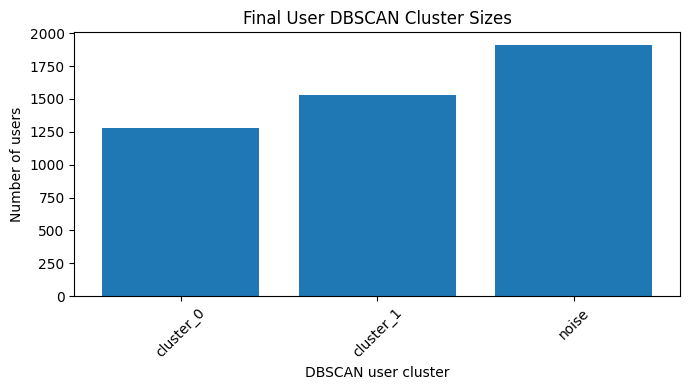

In [25]:
user_cluster_size_summary = (
    user_dbscan_labels
    .groupby(
        ["user_cluster", "user_cluster_label", "is_noise"],
        as_index=False,
    )
    .agg(users=("user_id", "nunique"))
    .sort_values(["is_noise", "user_cluster"])
    .reset_index(drop=True)
)

user_cluster_size_summary["share_users"] = (
    user_cluster_size_summary["users"] /
    user_cluster_size_summary["users"].sum()
)

user_dbscan_final_summary = pd.DataFrame([{
    "selected_run_key": final_user_run_key,
    "space_name": final_user_space_name,
    "preprocessing": final_user_summary["preprocessing"],
    "metric": final_user_metric,
    "eps": final_user_eps,
    "min_samples": final_user_min_samples,
    "eps_percentile": float(final_user_summary["eps_percentile"]),
    "n_users": int(user_dbscan_labels["user_id"].nunique()),
    "n_non_noise_clusters": int(
        user_dbscan_labels.loc[
            ~user_dbscan_labels["is_noise"],
            "user_cluster"
        ].nunique()
    ),
    "noise_users": int(user_dbscan_labels["is_noise"].sum()),
    "noise_share": float(user_dbscan_labels["is_noise"].mean()),
    "clustered_users": int((~user_dbscan_labels["is_noise"]).sum()),
    "clustered_share": float((~user_dbscan_labels["is_noise"]).mean()),
}])

user_cluster_size_summary.to_parquet(
    step3_results_dir / "user_cluster_size_summary.parquet",
    index=False,
)

user_cluster_size_summary.to_csv(
    step3_results_dir / "user_cluster_size_summary.csv",
    index=False,
)

user_dbscan_final_summary.to_parquet(
    step3_results_dir / "user_dbscan_final_summary.parquet",
    index=False,
)

user_dbscan_final_summary.to_csv(
    step3_results_dir / "user_dbscan_final_summary.csv",
    index=False,
)

display(user_cluster_size_summary.round(4))
display(user_dbscan_final_summary.round(4))

plt.figure(figsize=(7, 4))
plt.bar(
    user_cluster_size_summary["user_cluster_label"],
    user_cluster_size_summary["users"],
)
plt.xlabel("DBSCAN user cluster")
plt.ylabel("Number of users")
plt.title("Final User DBSCAN Cluster Sizes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Selected k-distance plot

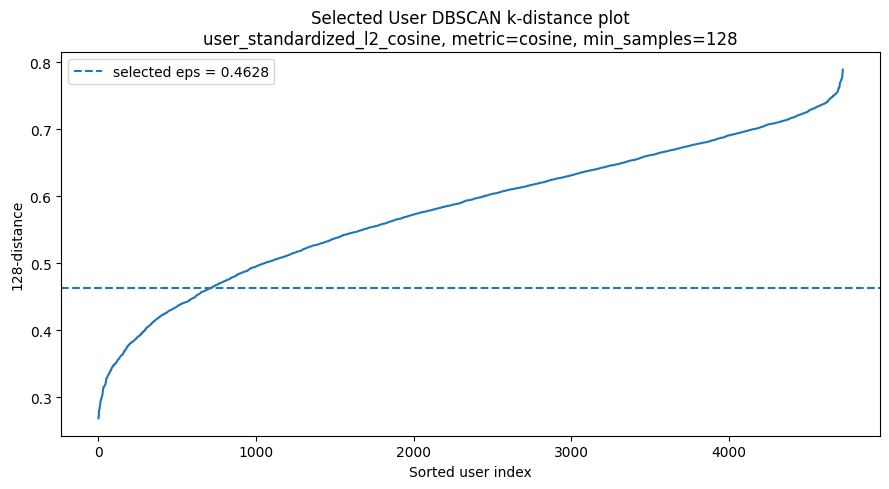

In [26]:
final_neighbors = NearestNeighbors(
    n_neighbors=final_user_min_samples,
    metric=final_user_metric,
    n_jobs=-1,
)

final_neighbors.fit(final_user_matrix)
final_distances, _ = final_neighbors.kneighbors(final_user_matrix)

final_k_distances = np.sort(final_distances[:, -1])

selected_user_k_distance_values = pd.DataFrame({
    "rank": np.arange(1, len(final_k_distances) + 1),
    "k_distance": final_k_distances,
})

selected_user_k_distance_values.to_parquet(
    step3_results_dir / "selected_user_k_distance_values.parquet",
    index=False,
)

selected_user_k_distance_values.to_csv(
    step3_results_dir / "selected_user_k_distance_values.csv",
    index=False,
)

plt.figure(figsize=(9, 5))
plt.plot(
    selected_user_k_distance_values["rank"],
    selected_user_k_distance_values["k_distance"],
)
plt.axhline(
    y=final_user_eps,
    linestyle="--",
    label=f"selected eps = {final_user_eps:.4f}",
)
plt.xlabel("Sorted user index")
plt.ylabel(f"{final_user_min_samples}-distance")
plt.title(
    "Selected User DBSCAN k-distance plot\n"
    f"{final_user_space_name}, metric={final_user_metric}, "
    f"min_samples={final_user_min_samples}"
)
plt.legend()
plt.tight_layout()

selected_k_distance_plot_path = (
    step3_results_dir / "selected_user_k_distance_plot.png"
)

plt.savefig(selected_k_distance_plot_path, dpi=150)
plt.show()

### 4.4 Load Step 1 artifacts for cluster profiling

In [27]:
required_step1_profile_files = [
    "train_split_model_universe.parquet",
    "train_pairs.parquet",
    "movies.parquet",
]

require_files(step1_results_dir, required_step1_profile_files)

step1_train_interactions_for_step3 = pd.read_parquet(
    step1_results_dir / "train_split_model_universe.parquet"
)

step1_train_pairs_for_step3 = pd.read_parquet(
    step1_results_dir / "train_pairs.parquet"
)

step1_movies_for_step3 = pd.read_parquet(
    step1_results_dir / "movies.parquet"
)

print("Loaded Step 1 profiling artifacts:")
print("step1_train_interactions_for_step3:", step1_train_interactions_for_step3.shape)
print("step1_train_pairs_for_step3:", step1_train_pairs_for_step3.shape)
print("step1_movies_for_step3:", step1_movies_for_step3.shape)

required_interaction_columns = {"user_id", "movie_id", "rating"}
required_pair_columns = {"user_id"}
required_movie_columns = {"movie_id", "genres"}

if not required_interaction_columns.issubset(step1_train_interactions_for_step3.columns):
    raise ValueError(
        "train_split_model_universe.parquet is missing columns: "
        f"{required_interaction_columns - set(step1_train_interactions_for_step3.columns)}"
    )

if not required_pair_columns.issubset(step1_train_pairs_for_step3.columns):
    raise ValueError(
        "train_pairs.parquet is missing columns: "
        f"{required_pair_columns - set(step1_train_pairs_for_step3.columns)}"
    )

if not required_movie_columns.issubset(step1_movies_for_step3.columns):
    raise ValueError(
        "movies.parquet is missing columns: "
        f"{required_movie_columns - set(step1_movies_for_step3.columns)}"
    )

# The final user labels should match the model-universe training users.
label_users = set(user_dbscan_labels["user_id"].unique())
train_interaction_users = set(step1_train_interactions_for_step3["user_id"].unique())

assert label_users == train_interaction_users, (
    "Final DBSCAN label users do not match Step 1 train model-universe users."
)

Loaded Step 1 profiling artifacts:
step1_train_interactions_for_step3: (759306, 5)
step1_train_pairs_for_step3: (5692244, 8)
step1_movies_for_step3: (3883, 3)


### 4.5 User cluster profiling

,user_cluster,user_cluster_label,is_noise,users,mean_ratings_in_train,median_ratings_in_train,mean_unique_items_in_train,mean_avg_train_rating,mean_rating_std,mean_train_pairs,median_train_pairs,min_train_pairs,max_train_pairs
0,0,cluster_0,False,1279,141.0930,72.0,141.0930,3.6830,1.0134,980.3370,644.0,18,2000
1,1,cluster_1,False,1532,194.4426,117.5,194.4426,3.7287,0.9816,1257.3727,1517.5,39,2000
2,-1,noise,True,1911,147.0235,112.0,147.0235,3.7243,1.0042,1314.5463,1608.0,34,2000


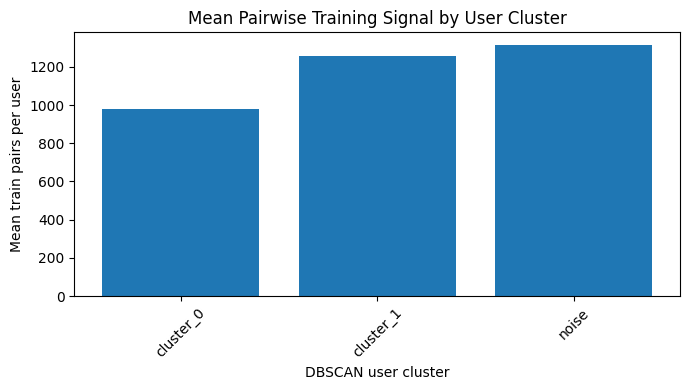

In [28]:
train_pair_counts_by_user = (
    step1_train_pairs_for_step3
    .groupby("user_id")
    .size()
    .rename("train_pairs")
    .reset_index()
)

user_train_activity_profile = (
    step1_train_interactions_for_step3
    .groupby("user_id", as_index=False)
    .agg(
        ratings_in_train=("rating", "size"),
        unique_items_in_train=("movie_id", "nunique"),
        avg_train_rating=("rating", "mean"),
        std_train_rating=("rating", "std"),
    )
)

user_cluster_profile_by_user = (
    user_dbscan_labels[
        ["user_id", "user_cluster", "user_cluster_label", "is_noise"]
    ]
    .merge(user_train_activity_profile, on="user_id", how="left")
    .merge(train_pair_counts_by_user, on="user_id", how="left")
)

user_cluster_profile_by_user["train_pairs"] = (
    user_cluster_profile_by_user["train_pairs"]
    .fillna(0)
    .astype(int)
)

user_cluster_profile_summary = (
    user_cluster_profile_by_user
    .groupby(
        ["user_cluster", "user_cluster_label", "is_noise"],
        as_index=False,
    )
    .agg(
        users=("user_id", "nunique"),
        mean_ratings_in_train=("ratings_in_train", "mean"),
        median_ratings_in_train=("ratings_in_train", "median"),
        mean_unique_items_in_train=("unique_items_in_train", "mean"),
        mean_avg_train_rating=("avg_train_rating", "mean"),
        mean_rating_std=("std_train_rating", "mean"),
        mean_train_pairs=("train_pairs", "mean"),
        median_train_pairs=("train_pairs", "median"),
        min_train_pairs=("train_pairs", "min"),
        max_train_pairs=("train_pairs", "max"),
    )
    .sort_values(["is_noise", "user_cluster"])
    .reset_index(drop=True)
)

user_cluster_profile_by_user.to_parquet(
    step3_results_dir / "user_cluster_profile_by_user.parquet",
    index=False,
)

user_cluster_profile_summary.to_parquet(
    step3_results_dir / "user_cluster_profile_summary.parquet",
    index=False,
)

user_cluster_profile_summary.to_csv(
    step3_results_dir / "user_cluster_profile_summary.csv",
    index=False,
)

display(user_cluster_profile_summary.round(4))

plt.figure(figsize=(7, 4))
plt.bar(
    user_cluster_profile_summary["user_cluster_label"],
    user_cluster_profile_summary["mean_train_pairs"],
)
plt.xlabel("DBSCAN user cluster")
plt.ylabel("Mean train pairs per user")
plt.title("Mean Pairwise Training Signal by User Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4.6 Fractional genre profile by final user DBSCAN cluster

In [29]:
movie_genres_for_step3 = step1_movies_for_step3[["movie_id", "genres"]].copy()

movie_genres_for_step3["genre_list"] = (
    movie_genres_for_step3["genres"]
    .fillna("")
    .str.split("|")
)

movie_genres_for_step3["n_genres"] = movie_genres_for_step3["genre_list"].apply(
    lambda values: len([genre for genre in values if genre != ""])
)

movie_genres_for_step3 = movie_genres_for_step3.explode("genre_list")
movie_genres_for_step3 = movie_genres_for_step3.rename(
    columns={"genre_list": "genre"}
)

movie_genres_for_step3["genre"] = movie_genres_for_step3["genre"].str.strip()

movie_genres_for_step3 = movie_genres_for_step3[
    movie_genres_for_step3["genre"].notna() &
    movie_genres_for_step3["genre"].ne("") &
    movie_genres_for_step3["n_genres"].gt(0)
].copy()

movie_genres_for_step3["genre_weight"] = 1.0 / movie_genres_for_step3["n_genres"]

clustered_train_interactions_for_step3 = (
    step1_train_interactions_for_step3
    .merge(
        user_dbscan_labels[
            ["user_id", "user_cluster", "user_cluster_label", "is_noise"]
        ],
        on="user_id",
        how="inner",
    )
    .merge(
        movie_genres_for_step3[["movie_id", "genre", "genre_weight"]],
        on="movie_id",
        how="left",
    )
)

clustered_train_interactions_for_step3["liked"] = (
    clustered_train_interactions_for_step3["rating"] >= 4
)

clustered_train_interactions_for_step3["weighted_rating_event"] = (
    clustered_train_interactions_for_step3["genre_weight"]
)

clustered_train_interactions_for_step3["weighted_liked_event"] = (
    clustered_train_interactions_for_step3["genre_weight"] *
    clustered_train_interactions_for_step3["liked"].astype(float)
)

genre_profile = (
    clustered_train_interactions_for_step3
    .groupby(
        ["user_cluster", "user_cluster_label", "is_noise", "genre"],
        as_index=False,
    )
    .agg(
        weighted_rating_events=("weighted_rating_event", "sum"),
        weighted_liked_events=("weighted_liked_event", "sum"),
        distinct_users=("user_id", "nunique"),
        mean_rating=("rating", "mean"),
    )
)

cluster_totals = (
    genre_profile
    .groupby("user_cluster", as_index=False)
    .agg(
        cluster_weighted_rating_events=("weighted_rating_events", "sum"),
        cluster_weighted_liked_events=("weighted_liked_events", "sum"),
    )
)

genre_profile = genre_profile.merge(
    cluster_totals,
    on="user_cluster",
    how="left",
)

genre_profile["share_of_cluster_likes"] = np.where(
    genre_profile["cluster_weighted_liked_events"] > 0,
    genre_profile["weighted_liked_events"] /
    genre_profile["cluster_weighted_liked_events"],
    np.nan,
)

genre_profile["like_rate"] = np.where(
    genre_profile["weighted_rating_events"] > 0,
    genre_profile["weighted_liked_events"] /
    genre_profile["weighted_rating_events"],
    np.nan,
)

# Global genre baseline, useful for seeing whether a cluster is over/under-represented.
global_genre_profile = (
    clustered_train_interactions_for_step3
    .groupby("genre", as_index=False)
    .agg(
        global_weighted_liked_events=("weighted_liked_event", "sum"),
    )
)

global_total_liked = global_genre_profile["global_weighted_liked_events"].sum()

global_genre_profile["global_share_of_likes"] = (
    global_genre_profile["global_weighted_liked_events"] /
    global_total_liked
)

genre_profile = genre_profile.merge(
    global_genre_profile[["genre", "global_share_of_likes"]],
    on="genre",
    how="left",
)

genre_profile["cluster_vs_global_like_lift"] = np.where(
    genre_profile["global_share_of_likes"] > 0,
    genre_profile["share_of_cluster_likes"] /
    genre_profile["global_share_of_likes"],
    np.nan,
)

genre_profile = (
    genre_profile
    .sort_values(
        [
            "user_cluster",
            "share_of_cluster_likes",
            "cluster_vs_global_like_lift",
            "weighted_liked_events",
        ],
        ascending=[True, False, False, False],
    )
    .reset_index(drop=True)
)

genre_profile["rank_within_cluster"] = (
    genre_profile
    .groupby("user_cluster")
    .cumcount() + 1
)

top_genres_per_user_cluster = genre_profile[
    genre_profile["rank_within_cluster"] <= 10
].copy()

genre_profile.to_parquet(
    step3_results_dir / "user_cluster_genre_profile_full.parquet",
    index=False,
)

top_genres_per_user_cluster.to_parquet(
    step3_results_dir / "top_genres_per_user_cluster.parquet",
    index=False,
)

top_genres_per_user_cluster.to_csv(
    step3_results_dir / "top_genres_per_user_cluster.csv",
    index=False,
)

display(
    top_genres_per_user_cluster[
        [
            "user_cluster_label",
            "genre",
            "rank_within_cluster",
            "weighted_liked_events",
            "distinct_users",
            "mean_rating",
            "share_of_cluster_likes",
            "global_share_of_likes",
            "cluster_vs_global_like_lift",
            "like_rate",
        ]
    ].round(4)
)

,user_cluster_label,genre,rank_within_cluster,weighted_liked_events,distinct_users,mean_rating,share_of_cluster_likes,global_share_of_likes,cluster_vs_global_like_lift,like_rate
0,noise,Drama,1,41029.4333,1910,3.8296,0.2410,0.2382,1.0118,0.6694
1,noise,Comedy,2,36013.3167,1910,3.6297,0.2115,0.2079,1.0173,0.5870
2,noise,Action,3,15604.6000,1908,3.5794,0.0916,0.0962,0.9525,0.5650
3,noise,Thriller,4,13688.3333,1904,3.6395,0.0804,0.0838,0.9592,0.6007
4,noise,Romance,5,10844.5000,1904,3.6834,0.0637,0.0615,1.0363,0.6022
5,noise,Sci-Fi,6,9524.4000,1886,3.5416,0.0559,0.0563,0.9941,0.5523
6,noise,Adventure,7,7169.4167,1887,3.5669,0.0421,0.0424,0.9921,0.5639
7,noise,Crime,8,5785.7833,1865,3.7825,0.0340,0.0342,0.9929,0.6513
8,noise,War,9,5507.8833,1869,3.9419,0.0323,0.0321,1.0065,0.7118
9,noise,Horror,10,5432.4333,1756,3.2843,0.0319,0.0328,0.9716,0.4591


# Save final Step 3 config

In [30]:
selected_user_dbscan_config = {
    "step": "Step 3: DBSCAN in embedding space",
    "selected_user_run_key": final_user_run_key,
    "entity_clustered_for_downstream": "users",
    "embedding_source": "Step 2 BPR user embeddings p_u",
    "space_name": final_user_space_name,
    "preprocessing": final_user_summary["preprocessing"],
    "metric": final_user_metric,
    "dimensions": int(final_user_summary["dimensions"]),
    "eps": final_user_eps,
    "min_samples": final_user_min_samples,
    "eps_percentile": float(final_user_summary["eps_percentile"]),
    "n_users": int(user_dbscan_labels["user_id"].nunique()),
    "n_non_noise_clusters": int(
        user_dbscan_labels.loc[
            ~user_dbscan_labels["is_noise"],
            "user_cluster"
        ].nunique()
    ),
    "noise_users": int(user_dbscan_labels["is_noise"].sum()),
    "noise_share": float(user_dbscan_labels["is_noise"].mean()),
    "clustered_users": int((~user_dbscan_labels["is_noise"]).sum()),
    "clustered_share": float((~user_dbscan_labels["is_noise"]).mean()),
    "item_dbscan_final_labels_saved": False,
    "item_dbscan_final_labels_reason": (
        "User DBSCAN is selected as the final downstream clustering artifact "
        "because Step 5 forms homogeneous and diverse groups of users. "
        "Item DBSCAN was explored but is not required for group formation."
    ),
    "random_seed": int(random_seed),
}

with open(step3_results_dir / "selected_user_dbscan_config.json", "w") as f:
    json.dump(
        make_json_serializable(selected_user_dbscan_config),
        f,
        indent=2,
    )

print("Saved:", step3_results_dir / "selected_user_dbscan_config.json")
display(pd.DataFrame([selected_user_dbscan_config]).T)

Saved: results_step3\selected_user_dbscan_config.json


,0
step,Step 3: DBSCAN in embedding space
selected_user_run_key,user_run_0841
entity_clustered_for_downstream,users
embedding_source,Step 2 BPR user embeddings p_u
space_name,user_standardized_l2_cosine
preprocessing,standardized_l2
metric,cosine
dimensions,64
eps,0.462779
min_samples,128


# Final Step 3 artifact audit

In [31]:
expected_step3_final_artifacts = [
    "user_dbscan_grid_summary.parquet",
    "user_dbscan_stage1_candidates.parquet",
    "user_dbscan_labels.parquet",
    "user_cluster_size_summary.parquet",
    "user_dbscan_final_summary.parquet",
    "selected_user_k_distance_values.parquet",
    "selected_user_k_distance_plot.png",
    "user_cluster_profile_by_user.parquet",
    "user_cluster_profile_summary.parquet",
    "user_cluster_genre_profile_full.parquet",
    "top_genres_per_user_cluster.parquet",
    "selected_user_dbscan_summary.parquet",
    "selected_user_dbscan_config.json",
]

step3_artifact_audit = pd.DataFrame([
    {
        "artifact": artifact,
        "exists": (step3_results_dir / artifact).exists(),
        "size_mb": (
            round((step3_results_dir / artifact).stat().st_size / (1024 ** 2), 4)
            if (step3_results_dir / artifact).exists()
            else None
        ),
    }
    for artifact in expected_step3_final_artifacts
])

display(step3_artifact_audit)

assert step3_artifact_audit["exists"].all(), (
    "Some final Step 3 artifacts are missing."
)

,artifact,exists,size_mb
0,user_dbscan_grid_summary.parquet,True,0.0668
1,user_dbscan_stage1_candidates.parquet,True,0.0141
2,user_dbscan_labels.parquet,True,0.0626
3,user_cluster_size_summary.parquet,True,0.0033
4,user_dbscan_final_summary.parquet,True,0.0080
5,selected_user_k_distance_values.parquet,True,0.0704
6,selected_user_k_distance_plot.png,True,0.0556
7,user_cluster_profile_by_user.parquet,True,0.1371
8,user_cluster_profile_summary.parquet,True,0.0085
9,user_cluster_genre_profile_full.parquet,True,0.0130


# Final Step 3 Summary: DBSCAN Clustering in Embedding Space

Step 3 applies DBSCAN to the learned BPR embeddings from Step 2. The goal is not only to cluster users, but to create a meaningful segmentation that can later support homogeneous and diverse group formation in Step 5.

## Final selected DBSCAN configuration

The final downstream clustering artifact is the user DBSCAN result, not the item clustering result, because Step 5 forms groups of users.

| Parameter | Value |
|---|---:|
| Entity clustered | Users |
| Embedding source | Step 2 BPR user embeddings |
| Preprocessing | standardized + L2 normalization |
| Metric | cosine |
| Dimensions | 64 |
| eps | 0.462779 |
| min_samples | 128 |
| eps percentile | 15.0 |
| Non-noise clusters | 2 |
| Clustered users | 2,811 |
| Noise users | 1,911 |
| Noise share | 40.47% |

## Final cluster sizes

| DBSCAN label | Interpretation | Users | Share |
|---:|---|---:|---:|
| 0 | non-noise cluster | 1,279 | 27.09% |
| 1 | non-noise cluster | 1,532 | 32.44% |
| -1 | noise | 1,911 | 40.47% |

The clustering therefore gives two large non-noise user segments and a large noise population.

## Interpretation

The DBSCAN result is useful but coarse. It should not be described as a rich many-community structure. Instead, it is better interpreted as a broad segmentation of the embedding space into two dense preference regions plus a substantial set of users that DBSCAN does not assign to any dense region.

The noise group is especially important to interpret carefully. DBSCAN noise does not mean that these users are invalid or low quality. In this project, noise users still have many ratings and many train pairs. The label means that their embeddings do not belong to either of the two high-density regions under the selected DBSCAN parameters.

## Why this result is still useful

Even though the clustering is coarse, it is valuable for downstream group recommendation because it supports three types of group construction:

- homogeneous groups from cluster 0;
- homogeneous groups from cluster 1;
- diverse groups that combine users from different DBSCAN regions, including noise users.

This makes DBSCAN useful as an experimental control variable for Step 5 and Step 6.

## Step 3 conclusion

DBSCAN produces a usable and interpretable user segmentation, but the result should be presented cautiously. The selected model finds two main dense preference regions and a large noise population. This is sufficient for controlled group formation, but it does not prove that the user base contains many fine-grained communities. The main downstream value of Step 3 is that it creates a principled basis for comparing homogeneous and diverse group recommendation settings.